In [5]:
import pandas as pd  
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("../Data/final/environment_data.csv")

In [1]:
def detect_outliers_iqr(df, city=None):
    if city is not None:
        df = df[df["City"] == city]
    
    outlier_summary = []
    outlier_rows = pd.DataFrame()

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col == "isWeekend" or col=="Electricity Consumption":
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers["Outlier_Feature"] = col   
        outlier_rows = pd.concat([outlier_rows, outliers])
        
        outlier_summary.append({
            "Feature": col,
            "Outliers_Count": len(outliers),
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2)
        })
    
    return pd.DataFrame(outlier_summary), outlier_rows



In [7]:
summary, outlier_rows = detect_outliers_iqr(df, city="Dubai")
print(summary.sort_values(by="Outliers_Count", ascending=False))

             Feature  Outliers_Count  Lower_Bound  Upper_Bound
3                NO2              17       -13.12       121.08
10        Wind_speed              15         6.62        19.23
2                 O3              10       -15.46       164.88
1               PM10              10       -36.71       226.04
4                 CO               5        69.12       846.12
9           Humidity               3        20.74        83.09
0              PM2.5               2        -3.11        82.77
5                SO2               1         0.62        41.08
7   Temperature_mean               0         9.06        51.23
6        Green_Space               0        51.00        51.00
8    Temperature_max               0        12.50        56.50
11          Pressure               0       982.00      1034.29


C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_11644\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_11644\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_11644\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

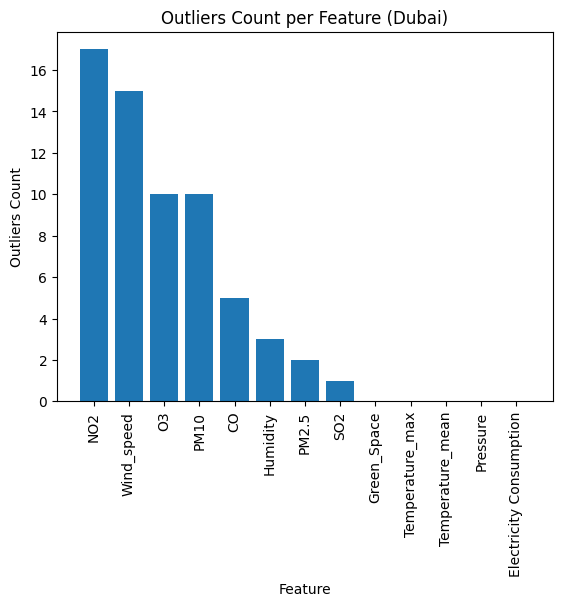

In [11]:


summary_sorted = summary.sort_values(by="Outliers_Count", ascending=False)

plt.figure()
plt.bar(summary_sorted["Feature"], summary_sorted["Outliers_Count"])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Outliers Count")
plt.title("Outliers Count per Feature (Dubai)")
plt.show()

Outliers were mainly concentrated in pollution-related features such as NO2, O3, and PM10, indicating occasional extreme pollution events in Dubai. Wind speed also showed several outliers, suggesting sudden weather changes. In contrast, temperature, pressure, and electricity consumption remained relatively stable with few or no outliers. Overall, the results suggest that air pollution levels are more variable and prone to sudden spikes compared to other environmental factors.

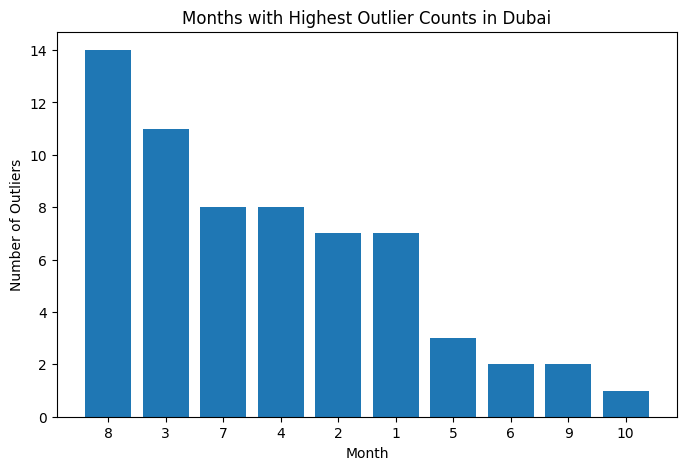

In [21]:
outlier_rows["Date"] = pd.to_datetime(outlier_rows["Date"])

monthly_outliers = outlier_rows["Date"].dt.month.value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(monthly_outliers.index.astype(str),
        monthly_outliers.values)

plt.xlabel("Month")
plt.ylabel("Number of Outliers")
plt.title("Months with Highest Outlier Counts in Dubai")

plt.show()

August showed the highest number of outliers, indicating that unusual environmental conditions or extreme pollution values occurred more frequently during this month. March and July also recorded relatively high outlier counts, suggesting increased environmental variability. On the other hand, months such as September and October showed fewer outliers, reflecting more stable conditions throughout those periods.

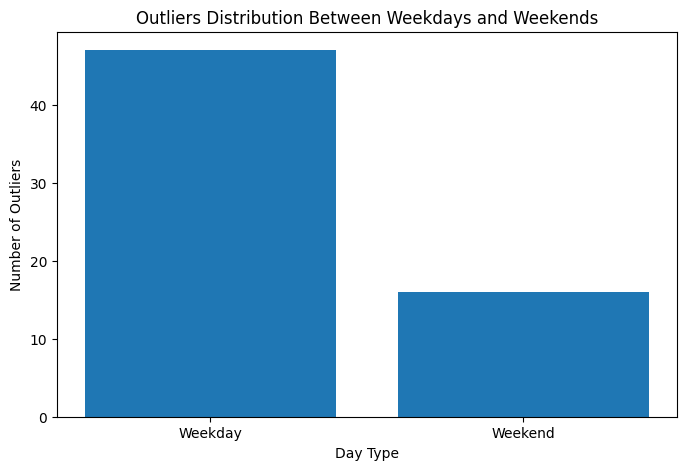

In [22]:
plt.figure(figsize=(8,5))
z=outlier_rows["isWeekend"].value_counts()
plt.bar(z.index.astype(str), z.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Outliers")
plt.title("Outliers Distribution Between Weekdays and Weekends")

plt.xticks([0,1], ["Weekday", "Weekend"])

plt.show()

Severe pollution events in Cairo appear to be more strongly associated with regular working days and daily human activities rather than weekends or holiday periods.

In [23]:
normal_rows = df[~df.index.isin(outlier_rows.index)]

outliers_mean = outlier_rows.mean(numeric_only=True)
normal_mean = normal_rows.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Outliers": outliers_mean,
    "Normal": normal_mean
})

comparison

,Outliers,Normal
PM2.5,5.216819e+01,1.978536e+01
PM10,1.358855e+02,3.503105e+01
O3,8.900794e+01,5.377316e+01
NO2,7.334974e+01,3.237277e+01
CO,5.660007e+02,3.343435e+02
SO2,2.309550e+01,1.429777e+01
Green_Space,5.100000e+01,1.062898e+02
Temperature_mean,3.085141e+01,1.877936e+01
Temperature_max,3.547619e+01,2.299840e+01
Humidity,4.665283e+01,6.501062e+01


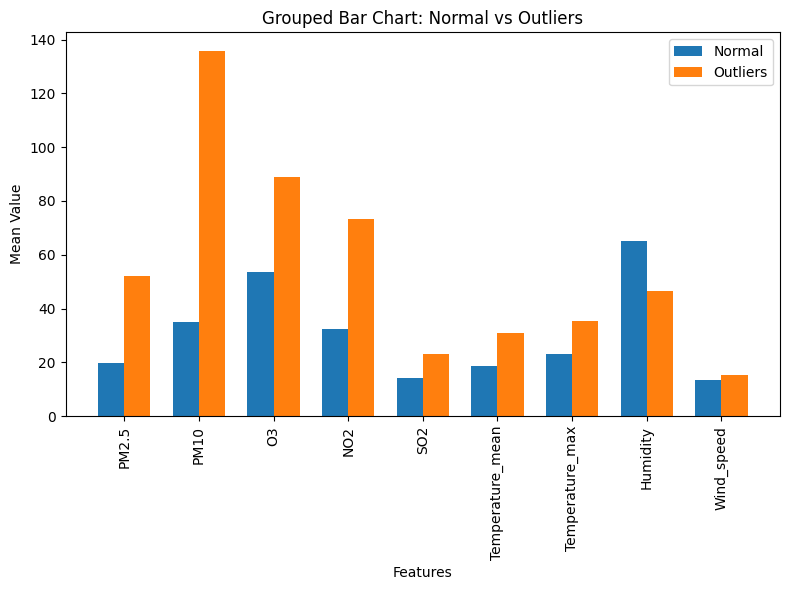

In [24]:

compare = comparison.drop(["Pressure", "isWeekend","CO","Electricity Consumption","Green_Space"])
features = compare.index

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    compare["Normal"],
    width=width,
    label="Normal"
)

plt.bar(
    x + width/2,
    compare["Outliers"],
    width=width,
    label="Outliers"
)

plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")

plt.legend()

plt.tight_layout()

plt.show()

Outlier values were significantly higher than normal values for several pollution-related features, particularly PM10, NO2, and PM2.5, indicating occasional extreme pollution spikes. In contrast, humidity outliers were lower than the normal average, suggesting unusual drops in humidity levels. Overall, pollution variables showed the largest deviations from typical environmental conditions.

In [25]:
others= comparison.loc[["Pressure","CO"],:]

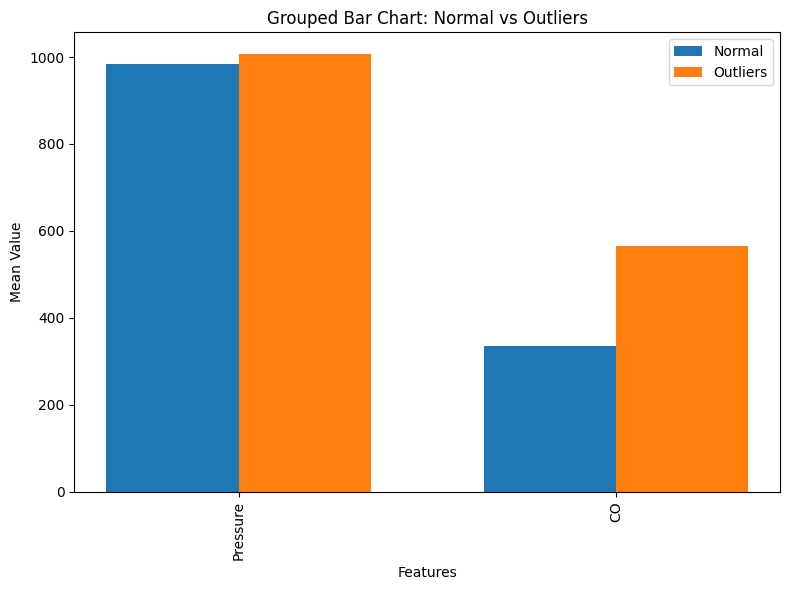

In [26]:
plt.figure(figsize=(8,6))
features=others.index
x=np.arange(len(features))
width=0.35
plt.bar(
    x-width/2,
    others["Normal"],
    width=width,
    label="Normal"
)
plt.bar(
    x+width/2,
    others["Outliers"],
    width=width,
    label="Outliers"
)
plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")
plt.legend()
plt.tight_layout()
plt.show()

CO outlier values were significantly higher than normal levels, indicating occasional extreme increases in carbon monoxide pollution. In contrast, pressure outliers showed only a slight increase compared to normal values, suggesting relatively stable atmospheric pressure conditions overall.